"""
Initial Results: Forecast Reliability in Electricity Demand Forecasting

This notebook presents the initial results of the project analyzing forecast reliability in electricity load forecasting.
The objective is to identify conditions under which forecasting models become unreliable.
"""

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [10]:
df = pd.read_csv("/data/PJME_hourly.csv")

In [12]:
df = pd.read_csv("/data/PJME_hourly.csv")

df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').set_index('Datetime')

df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


The dataset contains hourly electricity demand recorded in megawatts for the PJM energy region.

In [13]:
# Lag-1 persistence model
df['predicted'] = df['PJME_MW'].shift(1)

# Absolute forecast error
df['abs_error'] = (df['PJME_MW'] - df['predicted']).abs()

df.dropna(inplace=True)

A lag-1 persistence model is used as a transparent baseline forecast where the predicted value equals the previous hour’s demand.

In [14]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.day_name()
df['month'] = df.index.month

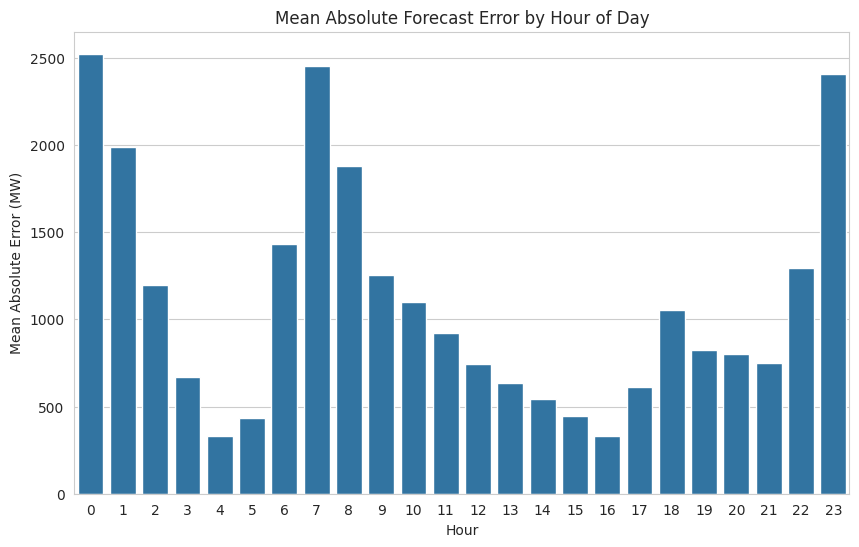

In [15]:
hourly_error = df.groupby('hour')['abs_error'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=hourly_error, x='hour', y='abs_error')
plt.title("Mean Absolute Forecast Error by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean Absolute Error (MW)")
plt.show()

In [ ]:
Forecast errors are higher during peak demand hours.

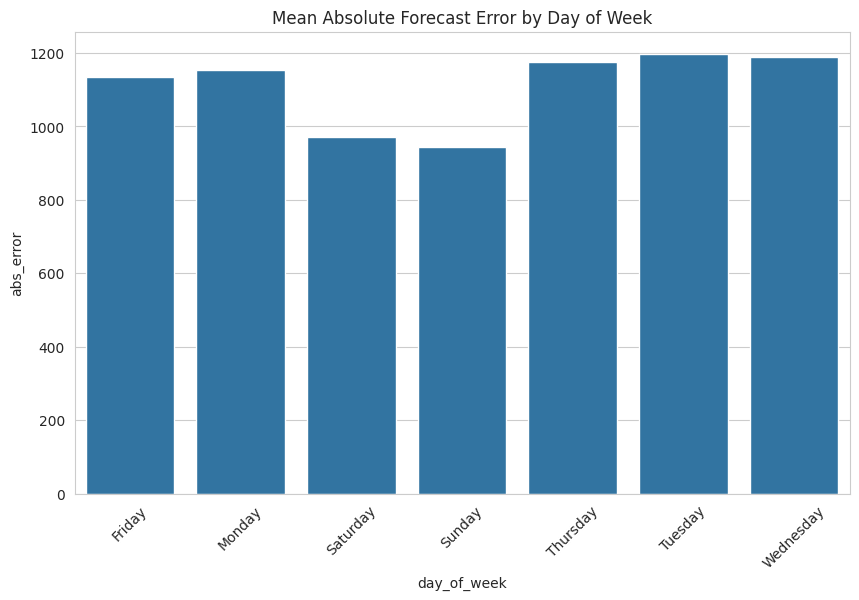

In [16]:
weekday_error = df.groupby('day_of_week')['abs_error'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=weekday_error, x='day_of_week', y='abs_error')
plt.xticks(rotation=45)
plt.title("Mean Absolute Forecast Error by Day of Week")
plt.show()

In [18]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df['season'] = df['month'].apply(get_season)

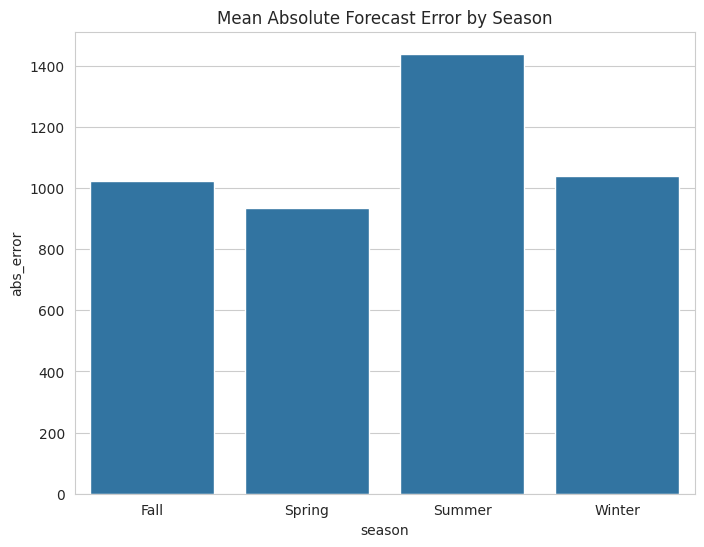

In [19]:
season_error = df.groupby('season')['abs_error'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=season_error, x='season', y='abs_error')
plt.title("Mean Absolute Forecast Error by Season")
plt.show()

In [20]:
df['demand_category'] = pd.qcut(
    df['PJME_MW'],
    q=[0,0.25,0.75,1],
    labels=['Low','Normal','High']
)

/tmp/ipykernel_636/610736449.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_error = df.groupby('demand_category')['abs_error'].mean().reset_index()


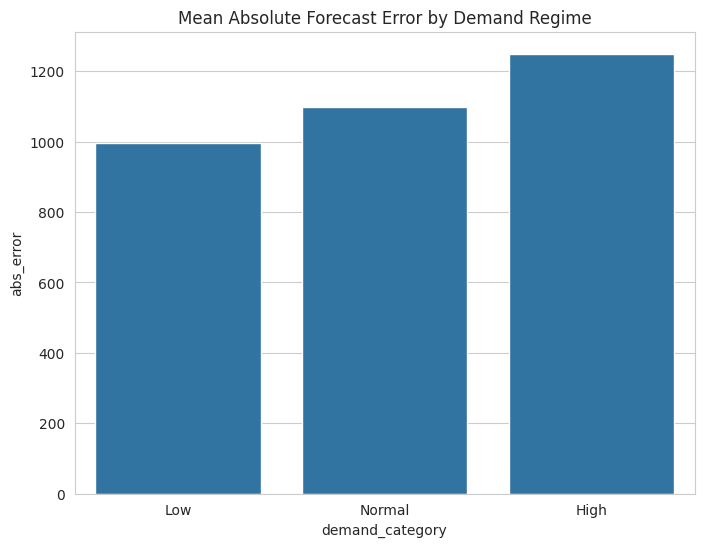

In [21]:
regime_error = df.groupby('demand_category')['abs_error'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=regime_error, x='demand_category', y='abs_error')
plt.title("Mean Absolute Forecast Error by Demand Regime")
plt.show()

he analysis demonstrates that forecasting reliability varies across operational conditions. Forecast errors increase during peak demand hours, extreme demand regimes, and seasonal demand peaks. These findings suggest that forecasting models exhibit condition-dependent reliability rather than uniform predictive performance.

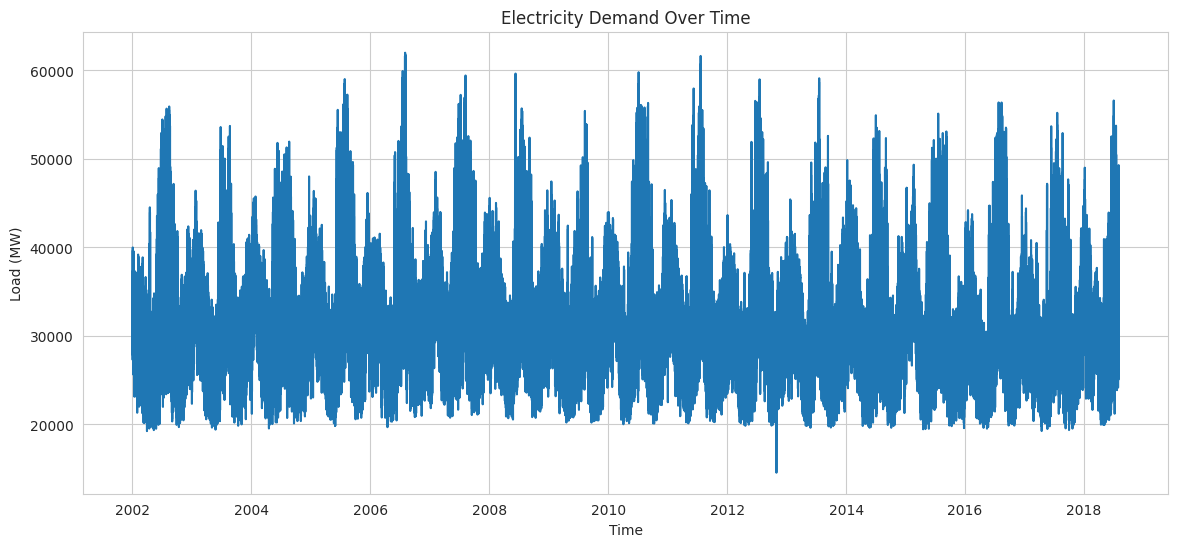

In [22]:
plt.figure(figsize=(14,6))
plt.plot(df['PJME_MW'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.show()

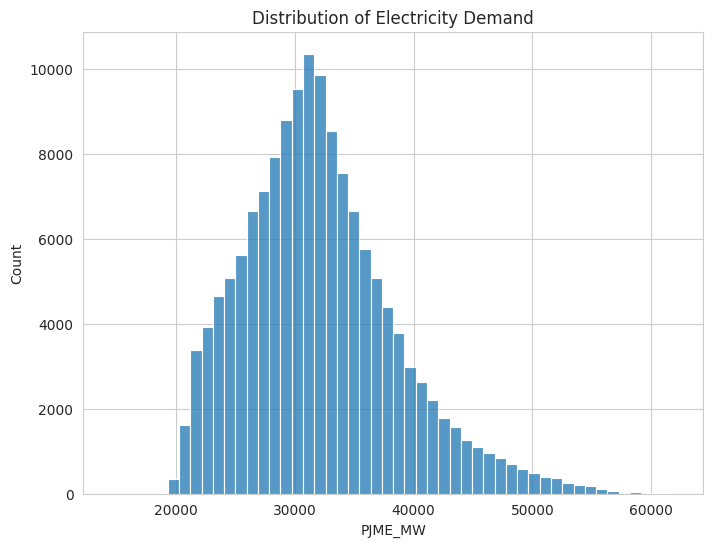

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(df['PJME_MW'], bins=50)
plt.title("Distribution of Electricity Demand")
plt.show()